In [217]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

## IMPORT LIBRARY

Berikut ini adalah import library, ini perlu karena untuk menjalankan seluruh bagian dari kode ini diperlukan libray libray di atas. Setiap library memiliki kegunaannya masing masing.

(720, 720, 3)


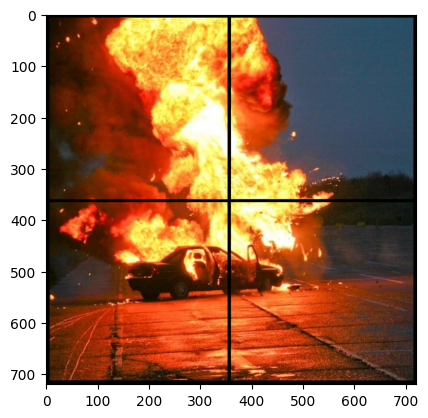

In [218]:
meledak0 = cv2.imread("Assets/Meledak.png")

meledak = cv2.cvtColor(meledak0, cv2.COLOR_BGR2RGB)
plt.imshow(meledak)
print(meledak.shape)

## MEMBACA DAN MENAMPILKAN GAMBAR
Berikut ini adalah bagain untuk membaca path dari gambar yang ingin di tampilkan. pembacaan path gambar ini menggunakan fungsi imread. Dan juga gambar yang sudah dibaca path-nya akan ditampilkan menggunakan imshow.

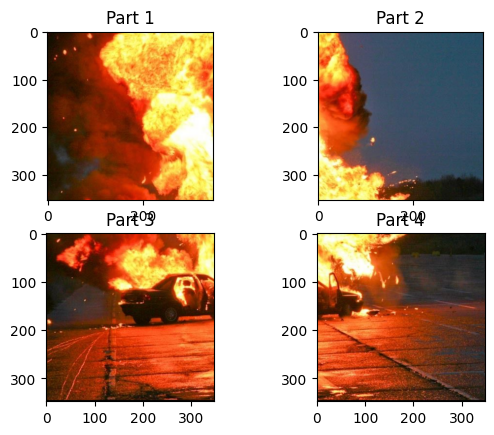

In [219]:
meledak1 = meledak[7:360, 5:353]
meledak2 = meledak[7:360, 367:715]
meledak3 = meledak[367:715, 5:353]
meledak4 = meledak[367:715, 367:715]
plt.subplot(2, 2, 1)
plt.title("Part 1")
plt.imshow(meledak1)
plt.subplot(2, 2, 2)
plt.title("Part 2")
plt.imshow(meledak2)
plt.subplot(2, 2, 3)
plt.title("Part 3")
plt.imshow(meledak3)
plt.subplot(2, 2, 4)
plt.title("Part 4")
plt.imshow(meledak4)


## MEMOTONG GAMBAR MENJADI 4 BAGIAN
Bagian ini memotong setiap bagian tergantung dari ukuran yang di inginkan, hal ini perlu untuk menghilangkan border hitam pada citra (penggabungan citra)

In [220]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

(701, 696, 3)


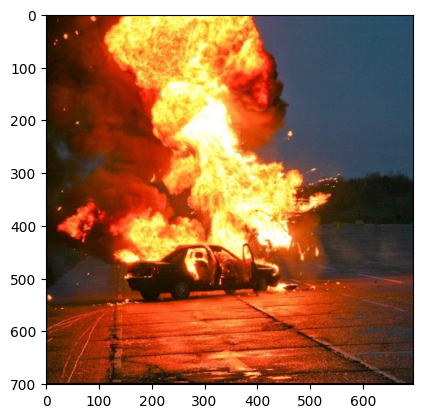

In [221]:
gabung_meledak1 = merge_image(meledak1, meledak2, "H")
gabung_meledak2 = merge_image(meledak3, meledak4, "H")
gabung_meledak = merge_image(gabung_meledak1, gabung_meledak2, "V")
plt.imshow(gabung_meledak)
print(gabung_meledak.shape)

## MENGGABUNGKAN SETIAP POTONGAN
Berikut adalah proses untuk menggabungkan tiap frame atau gambar dengan secara hoizontal dan vertikal

In [222]:
def ekualisasi(citra): 
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i][j]] += 1
    
    # Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    
    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(int)
    
    # Terapkan ke setiap pixel
    hasil = np.zeros_like(citra) 
    for i in range(height):
        for j in range(width):
            hasil[i][j] = cdf_normal[citra[i][j]]
    
    return hasil

(701, 696)


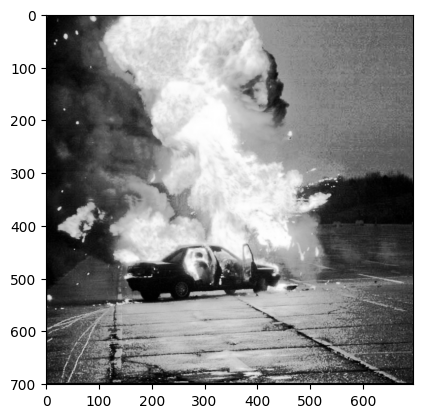

In [223]:
meledakGray0 = cv2.cvtColor(gabung_meledak, cv2.COLOR_RGB2GRAY)
meledakGray = ekualisasi(meledakGray0)
plt.imshow(meledakGray, cmap='gray')
print(meledakGray.shape)

## EKUALISASI CITRA MELEDAK
Bagian ini adalah proses untuk melakukan ekualisasi pada citra meledak.png, ini diperlukan untuk membuat distribusi intensitas piksel pada gambar meledak agar lebih merata. Hasil ekualisasi ini diperlukan untuk membandingkan histogram sebelum ekualisasi dan sesudah ekualisasi. Sebelum melakukan ekualisasi, citra dibuat dalam grayscale agar histogram nya dapat di ekualisasi.

In [224]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1
 
    return histogram 

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

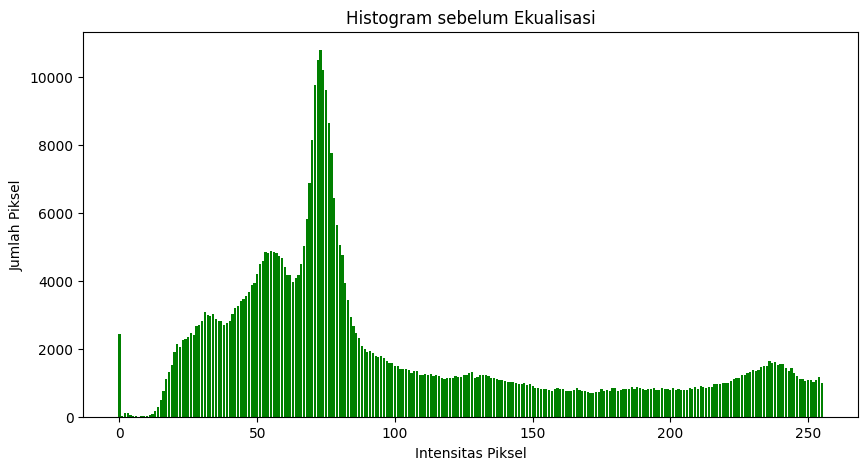

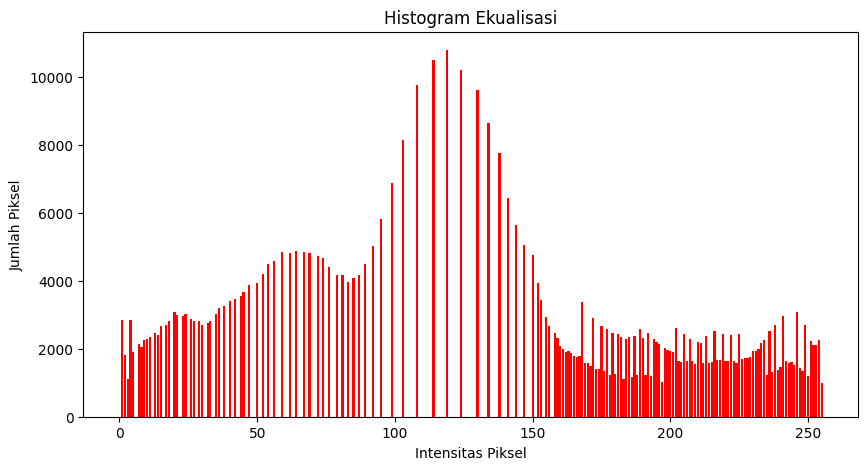

In [225]:
meledak_hist = buat_hist(meledakGray0)
plot_meledak_hist = plot_histogram(meledak_hist, "Histogram sebelum Ekualisasi", "green")
meledakEqual_hist = buat_hist(meledakGray)
plot_meledakEqual_hist = plot_histogram(meledakEqual_hist, "Histogram Ekualisasi", "red")


## PERBANDINGAN HISTOGRAM SEBELUM DAN SESUDAH EKUALISASI
Histogram sebelum ekualisasi (hijau) cenderung terkonsentrasi pada rentang intensitas tertentu, sedangkan histogram setelah ekualisasi (merah) menunjukkan distribusi yang lebih merata di seluruh rentang 0–255. Terlihat penggunaan ekualisasi adalah untuk meratakan distribusi intensitas suatu piksel citra.

In [226]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    # Hitung histogram citra asal
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            val = int(citra_asal[i][j])
            hist_asal[val] += 1
 
    # Hitung histogram citra target
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            val = int(citra_target[i][j])
            hist_target[val] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    # Hitung CDF dari index 1 sampai 255
    for k in range(1, 256):
        cdf_asal[k] = cdf_asal[k-1] + hist_asal[k]
        cdf_target[k] = cdf_target[k-1] + hist_target[k]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    # Mapping histogram: cari nilai j dengan selisih CDF terkecil
    for i in range(256):
        selisih_min = abs(cdf_asal[i] - cdf_target[0])
        map_hist[i] = 0
        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_min:
                selisih_min = selisih
                map_hist[i] = j
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    # Terapkan mapping ke citra asal
    for i in range(height):
        for j in range(width):
            hasil[i][j] = map_hist[int(citra_asal[i][j])]

    return hasil

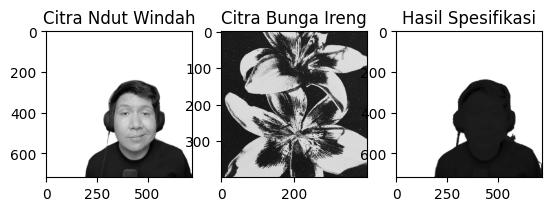

In [227]:
windah0 = cv2.imread("Assets/Windut.png")
windah1 = cv2.cvtColor(windah0, cv2.COLOR_BGR2GRAY)
bunga0 = cv2.imread("Assets/Bunga.png")
bunga = cv2.cvtColor(bunga0, cv2.COLOR_BGR2GRAY)

win_bung1 = spesifikasi_histogram(windah1, bunga)
plt.subplot(1, 3, 1)
plt.title("Citra Ndut Windah")
plt.imshow(windah1, cmap="gray")
plt.subplot(1, 3, 2)
plt.title("Citra Bunga Ireng")
plt.imshow(bunga, cmap="gray")
plt.subplot(1, 3, 3)
plt.title("Hasil Spesifikasi")
plt.imshow(win_bung1, cmap="gray")

## SPESIFIKASI GAMBAR WINDAH DAN BUNGA
Pada bagian ini, dibaca terlebih dulu path gambar untuk windah dan bunga. Dan ubah kedua citramenjadi citra grayscale. Spesifikasi dilakukan terhadap citra windah dan bunga. Citra windah berperan sbagai citra awal dan bunga sebagai citra targetnya. 

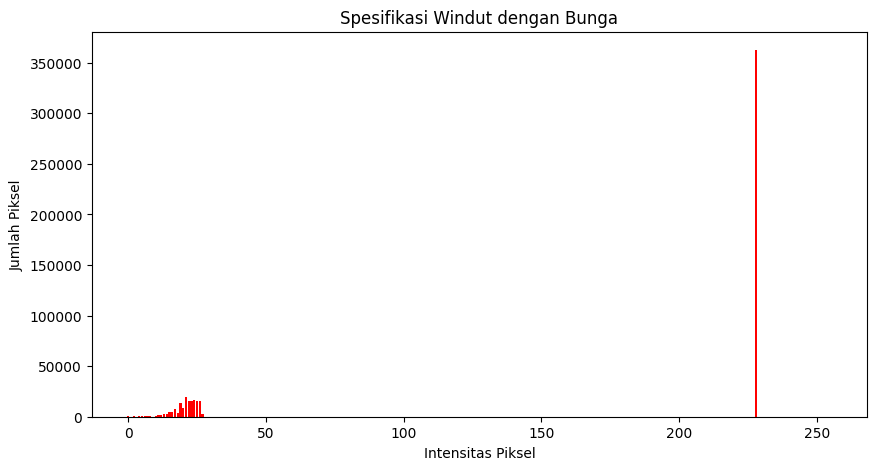

In [228]:
win_bung_hist = buat_hist(win_bung1)
plot_hist_win_bung = plot_histogram(win_bung_hist, "Spesifikasi Windut dengan Bunga", "red")

## HISTOGRAM SPESIFIKASI WINDAH DAN BUNGA
Pada bagian ini, dibuatkan histogram untuk hasil spesifikasi windah dan bunga. Lalu ditampilkan hasilnya, hasil ini dapat menjadi visualisasi terkait bagaimana distribusi intensitas piksel setelah dua citra tersebut di spesifikasi.

In [229]:
win_bung2 = win_bung1[0: 701,0:696]
windah = windah1[0: 701,0:696]

## CROP CITRA
Pada bagian ini, dilakukan cropping pada citra spesifikasi windah dengan bunga dan citra windah. Pemotongan ini dilakukan agar keuda citra yang akan diproses memiliki ukuran yang sama.

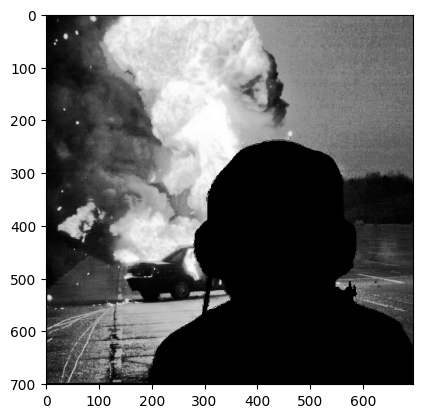

In [230]:
win_bung = cv2.cvtColor(win_bung2, cv2.COLOR_BGR2RGB)
hasil = np.zeros(meledakGray.shape, dtype=meledakGray.dtype)

for i in range(hasil.shape[0]):
    for j in range(hasil.shape[1]):
        if win_bung1[i,j] > 150:
            hasil[i,j] = meledakGray[i,j]

plt.imshow(hasil, cmap="gray")
plt.show()

## MASKING HASIL SPESIFIKASI DENGAN CITRA MELEDAK
Pada bagian ini dilakukan masking, yang dimana memanfaatkan hasil spesifikasi sebelumnya dengan citra meledak sebagai background. Digunakan perulangan untuk menampilkan ukuran tinggi dan lebar dari citra meledak sebagai background. Jika nilai piksel di hasil spesifikasi lebih dari 150 (area terang). Area gelap pada hasil spesifikasi (nilai ≤ 150) dibiarkan bernilai 0 (hitam). Hasilnya adalah efek visual di mana ledakan hanya muncul di area yang terang dari citra Windah-Bunga.

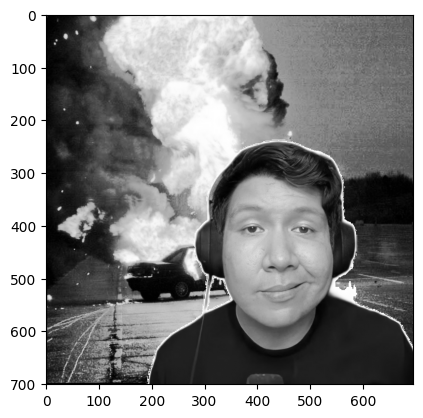

(701, 696)


In [231]:
hasil_win = np.zeros_like(hasil, dtype=int)

for i in range(hasil.shape[0]):
    for j in range(hasil.shape[1]):
        if windah[i,j] > 254: 
            hasil_win[i,j] = hasil[i,j]
        else :
            hasil_win[i,j] = windah[i, j]

plt.imshow(hasil_win, cmap="gray")
plt.show()
print(hasil_win.shape)

## PENAMBAHAN CITRA WINDAH PADA HASIL MASKING
Pada bagian ini, cara nya hampir sama dengan masking sebelumnya, perbedaannya terdapat pada citra mana yang ingin di masking. Pada kasus ini, dilakukan masking antara hasil masking sebelumnya(sebagai background) dan citra windah. Jika nilai piksel windah sangat terang (> 254), yang kemungkinan adalah area background/latar putih. Di luar area tersebut, piksel dari windah asli yang dipakai.

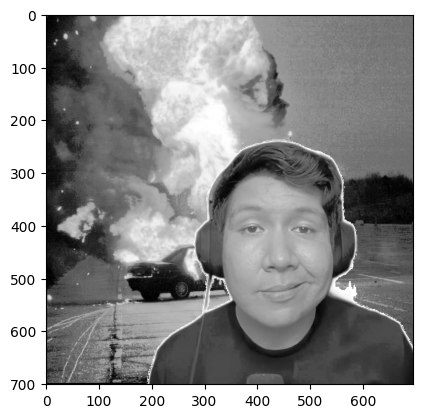

In [253]:
langit0 = cv2.imread("Assets/Langit.png")
langitGray = cv2.cvtColor(langit0, cv2.COLOR_BGR2GRAY)

spek_windak = spesifikasi_histogram(hasil_win, langitGray)
plt.imshow(spek_windak, cmap="gray")

## SPESIFIKASI HASIL MASKING TERAKHIR DENGAN CITRA LANGIT

Pada bagian, ini dilakukan spesifikasi antara hasil masking dengan citra langit. Baca terlebih dulu path citra langit, lalu citra tersebut diubah menjadi citra grayscale agar bisa di spesifikasi. Hasilnya citra akan memiliki warna yang tidak terlalu gelap.

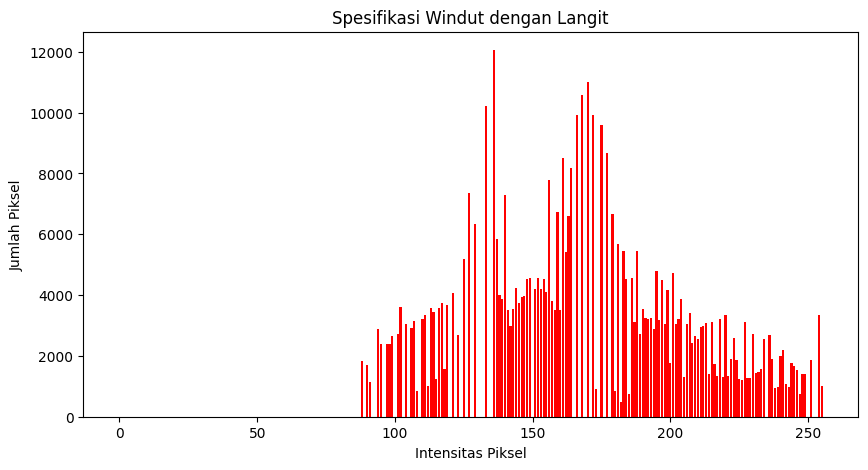

In [249]:
hist_windak = buat_hist(spek_windak)

plot_hist_windak = plot_histogram(hist_windak, "Spesifikasi Windut dengan Langit", "red")

## HISTOGRAM HASIL SPESIFIKASI MASKING TERAKHIR DENGAN LANGIT
Pada bagian ini, dibuatkan histogram dari hasil spesifikasi kedua citra. Hal ini penting untuk melihat distribusi intensitas piksel dari hasil spesifikasi.

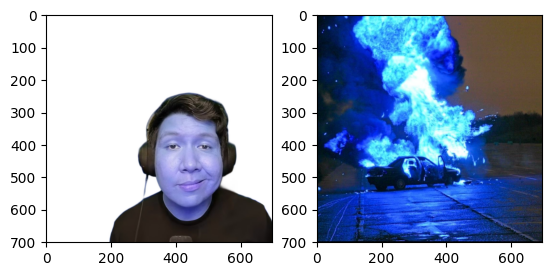

In [234]:
bg_baru = cv2.cvtColor(gabung_meledak, cv2.COLOR_RGB2BGR)
gambar_baru1 = cv2.imread("Assets/Windut.png")
gambar_baru = gambar_baru1[0:701, 0:696]
plt.subplot(1, 2, 1)
plt.imshow(gambar_baru)
plt.subplot(1, 2, 2)
plt.imshow(bg_baru)

## LOAD ULANG GAMBAR WINDAH DAN GUNAKAN PENGGABUNGAN CITRA MELEDAK SEBELUM GRAYSCALE
Pada bagian ini, dilakukan pembacaan ulang citra windah untuk mendapatkan hasil yang sesuai. Pemanggilan ulang menggunakan cv2. Pada bagian background baru, dilakukan pengubahan color dari penggabungan citra meledak sebelum grayscale yaitu dari RGB ke BGR, hal ini dilakukan untuk mengubah warna dari backgorun agar menghasilkan warna biru yang dominan.

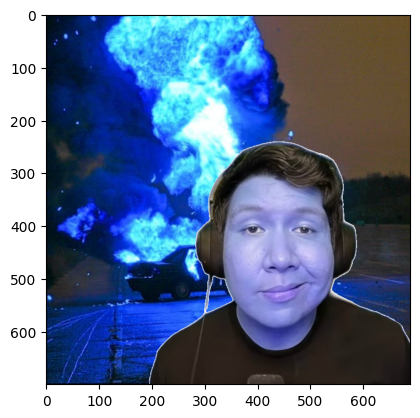

In [235]:
hasil = np.zeros_like(gambar_baru, dtype=int)


for i in range(bg_baru.shape[0]):
    for j in range(bg_baru.shape[1]):
    
        if gambar_baru[i, j, 0] > 240:
            hasil[i, j] = bg_baru[i, j]
        else:
            hasil[i,j] = gambar_baru[i, j]
            
# 3. Tampilkan hasil
hasil = hasil[0:700, 0: 690]
plt.imshow(hasil, cmap="gray")
plt.show()

## MASKING BACKGROUND SEBELU GRAYSCALE DENGAN WINDAH YANG DIPANGGIL ULANG
Pada bagian ini, dilakukan proses yang sama dengan proses masking sebelumnya. Yang dimana citra windah yang baru akan di masking dengan background sebelum grayscale. Saat nilai channel citra windah itu > 240, dibuat lah warna putih pada citra windah menjadi backgroun meledak yang biru. Dan sebaliknya, jika <240 dibuat menjadi citra windah.

## ANALISIS
Pada modul ini, digunakan spesifikasi dan ekualisasi histogram. Ekualisasi akan membuat distribusi intensitas piksel lebih merata, sedangkan spesifikasi akan membuat distribusi intensitas piksel mengikuti citra targetnya. Saat melakukan masking, dibuat kedua citra yang akan diproses memiliki ukuran yang sama agar tidak terjadi error (baik dalam channel dan dimensi). Penggantian warna RGB dan BGR sangat diperlukan karena pengubahan warna dari keinginan soal, yang dimana untuk bagian terakhir diperlukan channel BGR karena warna biru dominan yang diinginkan